# Exploring Relationships

## 1. Importing Libraries and Data

1a. Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import scipy

1b. Data

In [2]:
path = r'C:\Users\chris\Desktop\Upskilling\CareerFoundry\Data Immersion\Achievement 6_Advanced Analytics and Dashboard Design\11-2025 Coffee Lifestyle Factors Analysis'
df = pd.read_csv(os.path.join(path, '02. Data', 'Prepared Data', 'synthetic_coffee_health_clean.csv'), index_col = False)

## 2. Exploring Relationships

Creating a correlation matrix of the key factors for my questions

In [3]:
df_corr = df[['Coffee_Intake', 'Age', 'Heart_Rate', 'Sleep_Hours', 'BMI', 'Physical_Activity_Hours']]

In [4]:
df_corr.corr()

,Coffee_Intake,Age,Heart_Rate,Sleep_Hours,BMI,Physical_Activity_Hours
Coffee_Intake,1.000000,-0.012155,0.060123,-0.190291,-0.008330,0.004782
Age,-0.012155,1.000000,-0.000197,0.005010,0.008627,0.005931
Heart_Rate,0.060123,-0.000197,1.000000,-0.036219,-0.009362,-0.002919
Sleep_Hours,-0.190291,0.005010,-0.036219,1.000000,0.008463,-0.011228
BMI,-0.008330,0.008627,-0.009362,0.008463,1.000000,0.002042
Physical_Activity_Hours,0.004782,0.005931,-0.002919,-0.011228,0.002042,1.000000


Creating a correlation heatmap

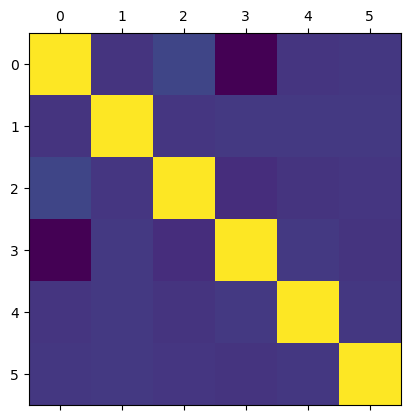

In [5]:
plt.matshow(df_corr.corr())
plt.show()

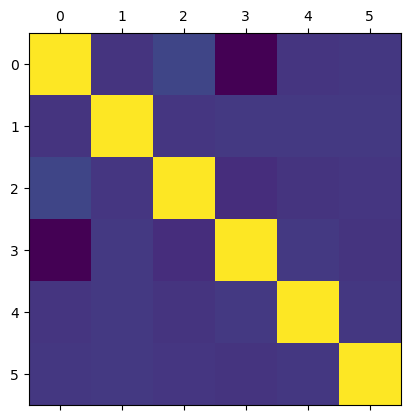

In [6]:
plt.matshow(df_corr.corr())
plt.savefig("out.png") 

In [7]:
corr_matrix = df_corr.corr()

In [8]:
hasattr(corr_matrix, 'columns')

True

RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

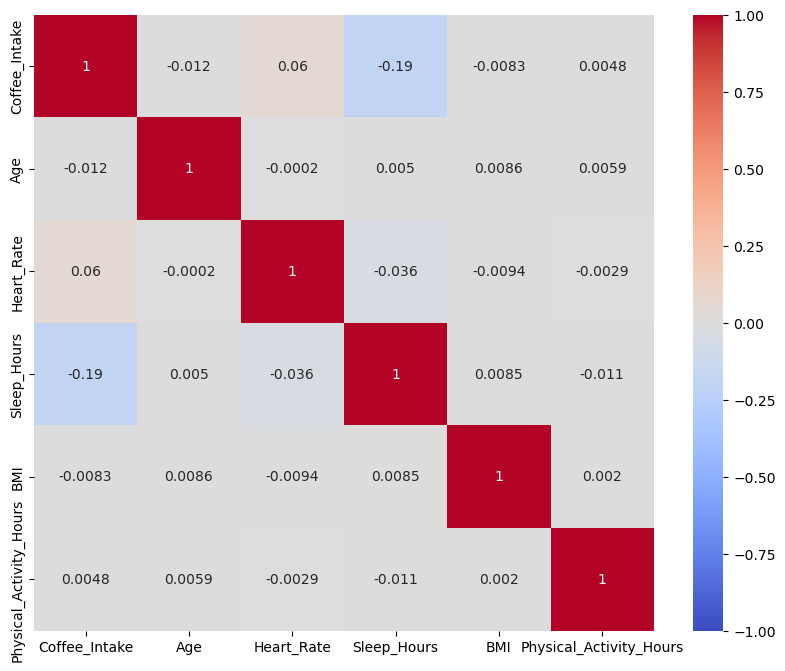

In [9]:
plt.figure(figsize=(10, 8))
heatmap = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.title('Correlation Matrix')
feature_names = corr_matrix.columns
plt.tight_layout()
plt.show()

The variables with the strongest correlation are Sleep_Hours and Coffee_Intake, which shows a weak negative correlation - the higher the coffee intake, the lower the number of hours of sleep. Certainly those sleeping for 9 or more hours tend to drink less than 5 cups of coffee a day. The highest concentration of people sleeping for more than 8.5 hours don't drink any coffee at all.

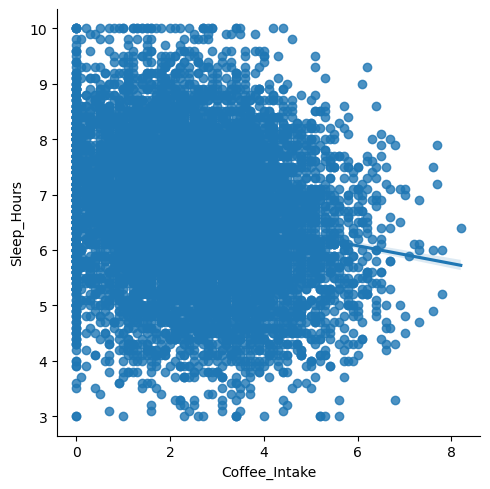

In [10]:
sns.lmplot(x = 'Coffee_Intake', y = 'Sleep_Hours', data = df_corr)

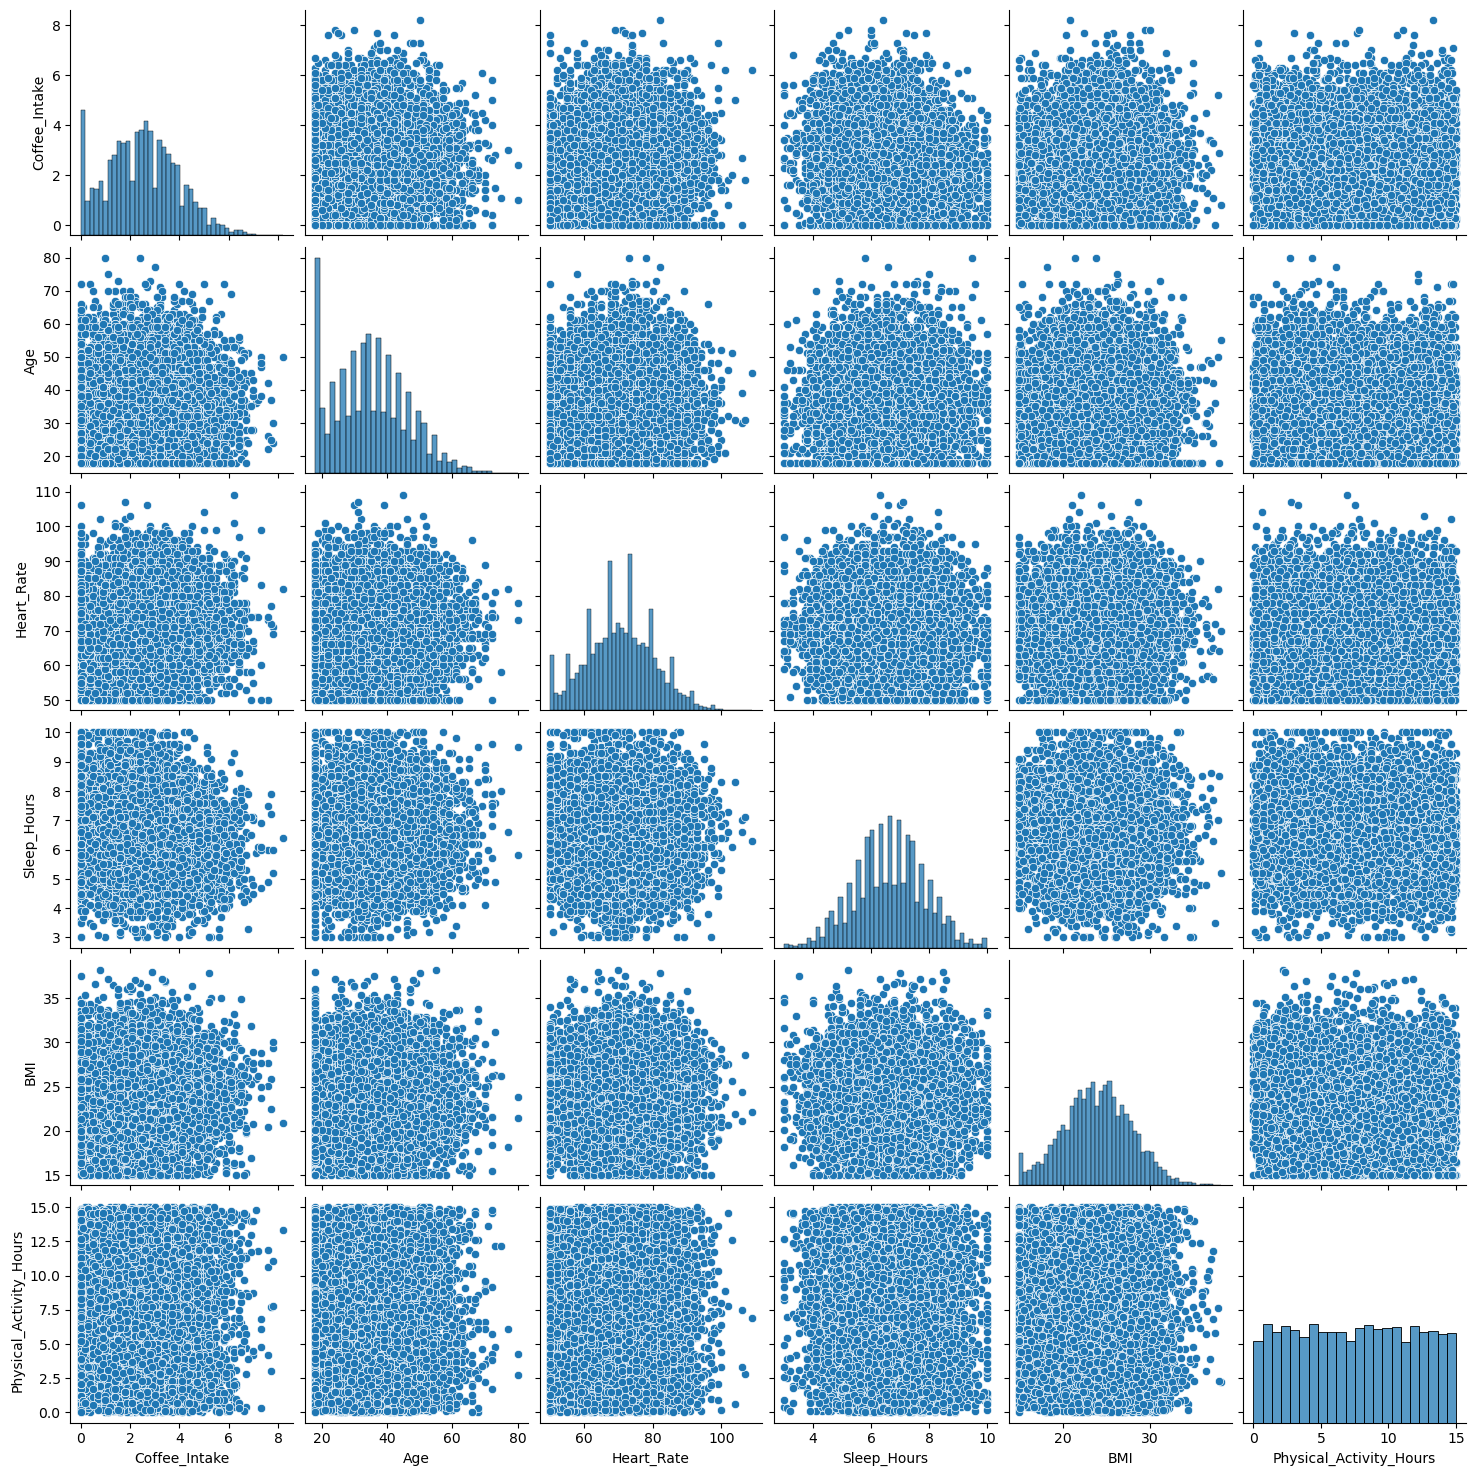

In [11]:
g = sns.pairplot(df_corr)

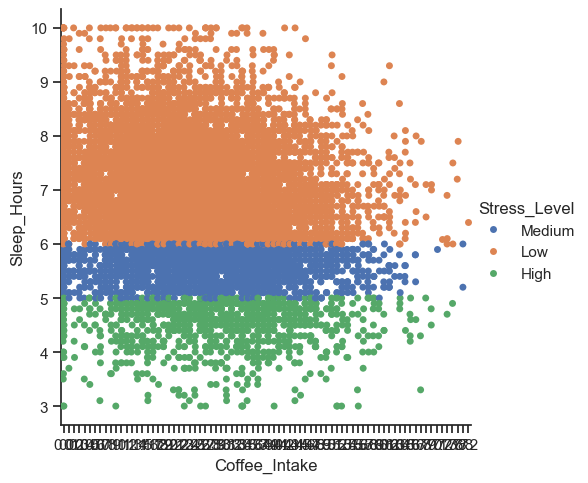

In [12]:
sns.set(style="ticks")
g = sns.catplot(x="Coffee_Intake", y="Sleep_Hours", hue="Stress_Level", data=df)

Interesting to see here when we add a hue for stress level to the scatterplot showing the relationship of coffee in take and the number of hours, we can see a relationship wit

<Axes: xlabel='Sleep_Hours', ylabel='Count'>

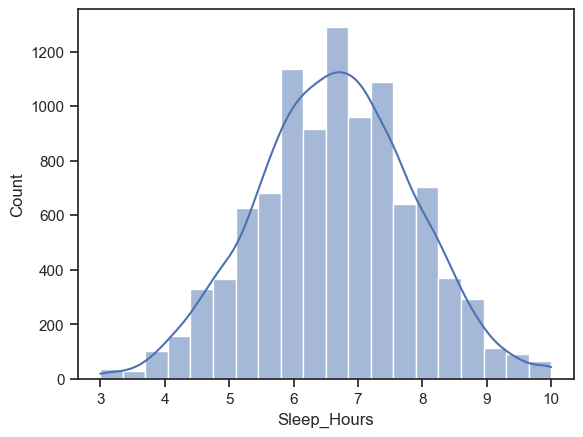

In [13]:
sns.histplot(df['Sleep_Hours'], bins = 20, kde = True)

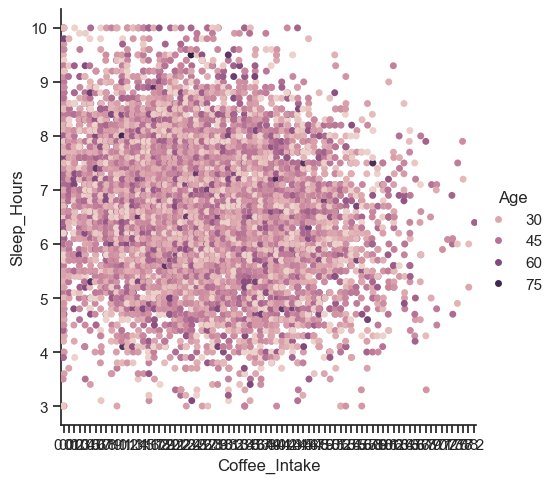

In [14]:
sns.set(style="ticks")
g = sns.catplot(x="Coffee_Intake", y="Sleep_Hours", hue="Age", data=df)

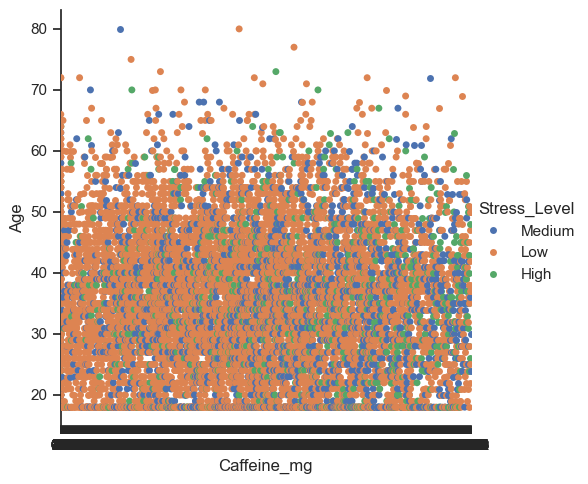

In [15]:
sns.set(style="ticks")
h = sns.catplot(x="Caffeine_mg", y="Age", hue="Stress_Level", data=df)

From this visualisation there appears to be a higher concentration of perople with medium/high stress levels in younger people who drink more caffeine. However it is not clear as to whether caffeine consumption leads to higher levels of stress (or vis versa) as there is a lot of people with low stress level who also drink higher levels of caffeine. Howere this would be interesting to explore further, namely do younger people with higher stress levels drink more coffee.

Visualising some of my questions

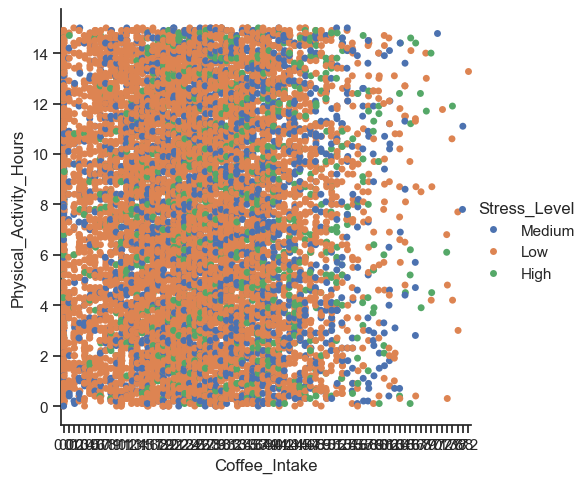

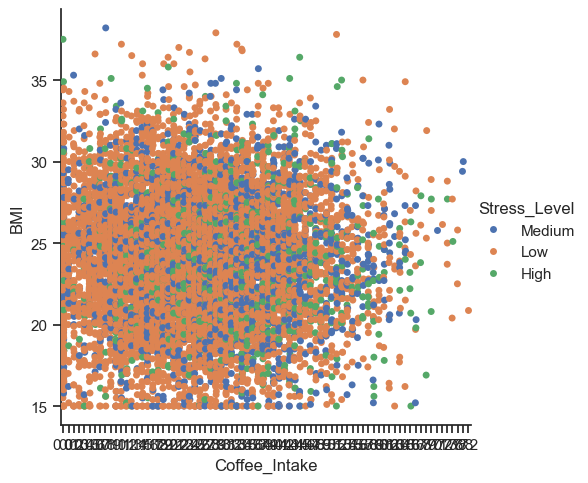

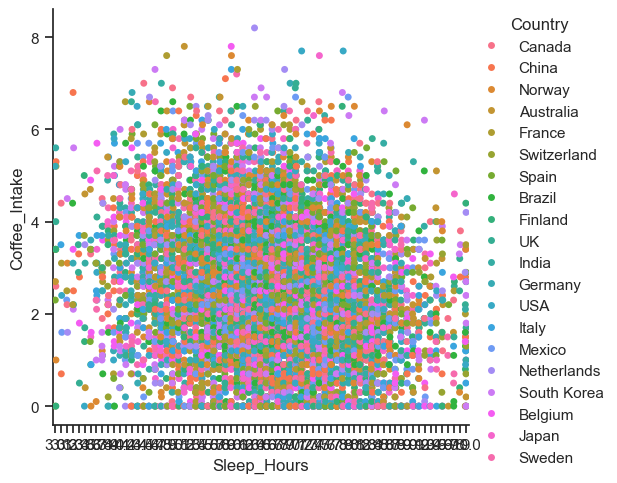

In [16]:
i = sns.catplot(x="Coffee_Intake", y="Physical_Activity_Hours", hue="Stress_Level", data=df)
j = sns.catplot(x="Coffee_Intake", y="BMI", hue="Stress_Level", data=df)
k = sns.catplot(x="Sleep_Hours", y="Coffee_Intake", hue="Country", data=df)

Creating a categorical variable that splits the "BMI" column into categories

In [17]:
df.loc[df['BMI'] < 20, 'BMI_Level'] = 'Low'

In [18]:
df.loc[(df['BMI'] >= 20) & (df['BMI'] < 28), 'BMI_Level'] = 'Average'

In [19]:
df.loc[df['BMI'] >= 28, 'BMI_Level'] = 'High'

In [20]:
df['BMI_Level'].value_counts(dropna = False)

BMI_Level
Average    6900
High       1577
Low        1523
Name: count, dtype: int64

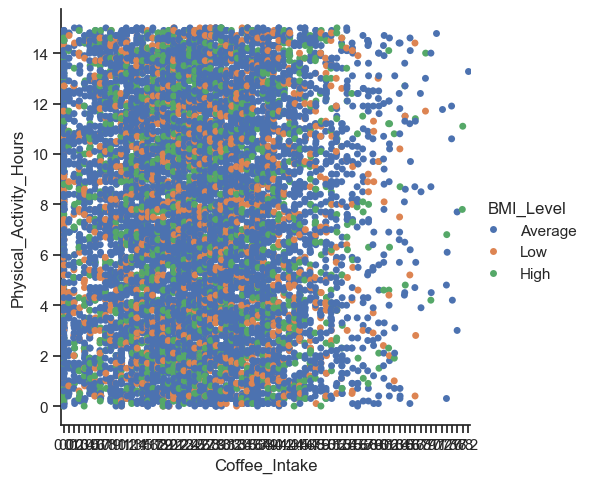

In [21]:
l = sns.catplot(x="Coffee_Intake", y="Physical_Activity_Hours", hue="BMI_Level", data=df)

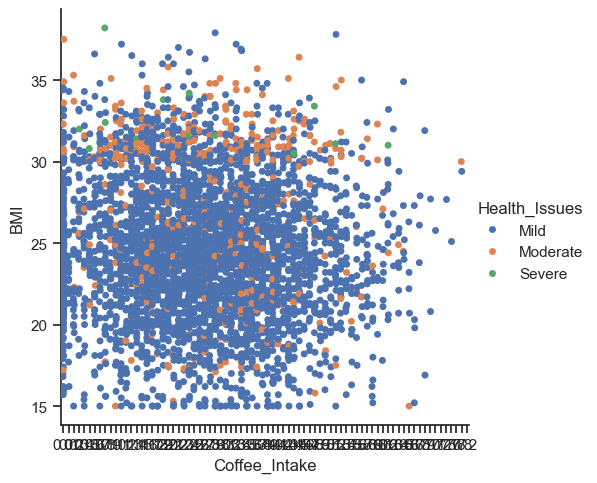

In [22]:
m = sns.catplot(x="Coffee_Intake", y="BMI", hue="Health_Issues", data=df)

In this visualisation we can see a pattern that people with severe health issues have higher BMI. Some thing to explore further could be does a higher BMI lead to increased health issues

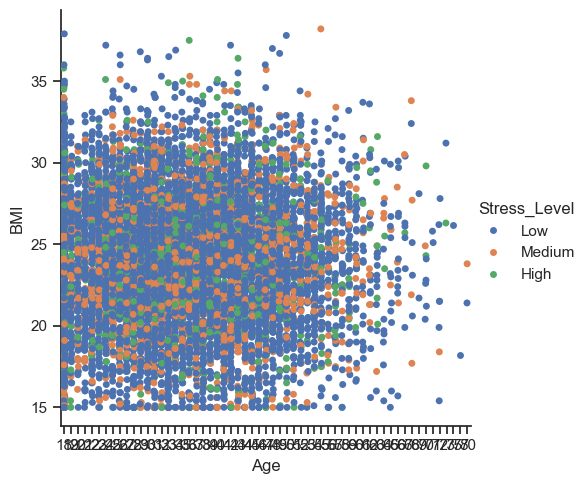

In [24]:
o = sns.catplot(x="Age", y="BMI", hue="Stress_Level", data=df)

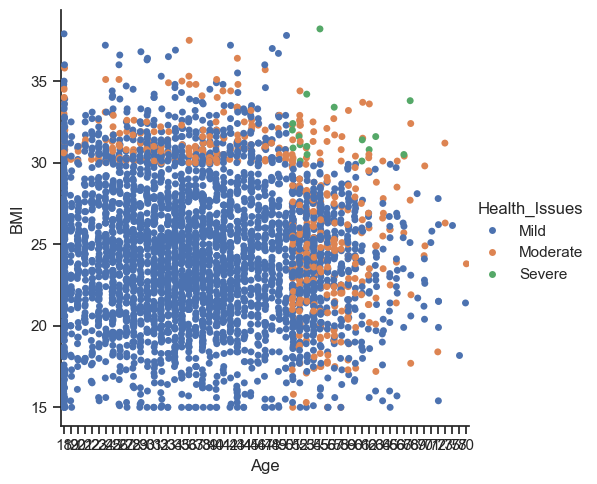

In [23]:
n = sns.catplot(x="Age", y="BMI", hue="Health_Issues", data=df)

There is an interesting pattern to this visualisation. It appears that people with low and average BMI tend to develop health issues from a around 50, whereas more younger people (under 50) wth a higher BMI have moderate health issues. The highest concentration of severe health issues is found in people who are older (50+) and who have higher BMI (0ver 30). It might be interesting to explore what causes younger people to have high BMI.

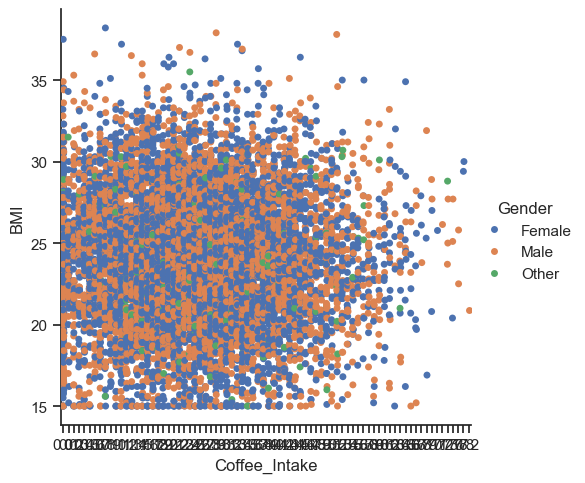

In [25]:
p = sns.catplot(x="Coffee_Intake", y="BMI", hue="Gender", data=df)

Whislt the correlation is low between these two variables, we can see that in general males drink more cups of coffee per day than females and male, higher coffee drinkers have lower BMIs than the females high coffee drinkers. People with higher BMIs tend drink less coffee

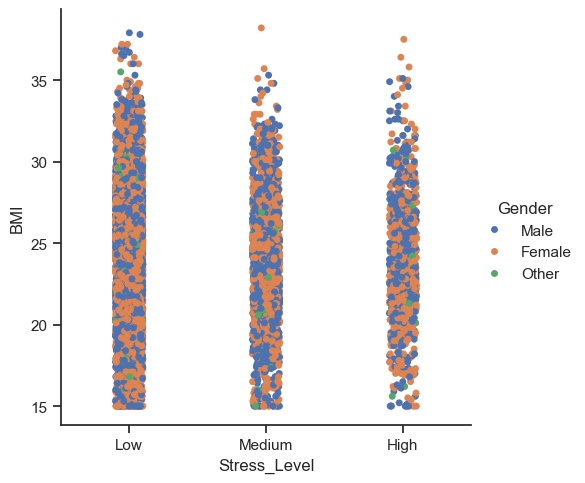

In [26]:
o = sns.catplot(x="Stress_Level", y="BMI", hue="Gender", data=df)

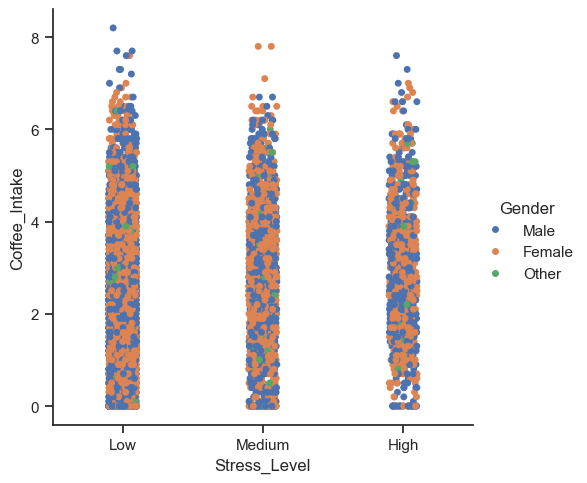

In [27]:
o = sns.catplot(x="Stress_Level", y="Coffee_Intake", hue="Gender", data=df)

Interestingly,the highest coffee drinkers are male and have low levels of stress, compared to the highest female coffee drinkers having medium stress levels. The highest concentration of low coffee drinkers have low stress. The highest concentration with high stress levels tend to drink between 2 and 4 cups of coffee with much few drinking more than 5, unlike those who have medium and low stress levels, where we see a high number of drinkers consuming more than 5 cups per day.

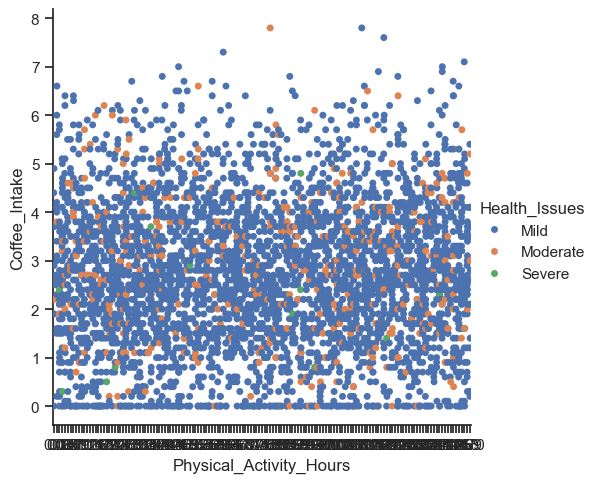

In [31]:
n = sns.catplot(x="Physical_Activity_Hours", y="Coffee_Intake", hue="Health_Issues", data=df)

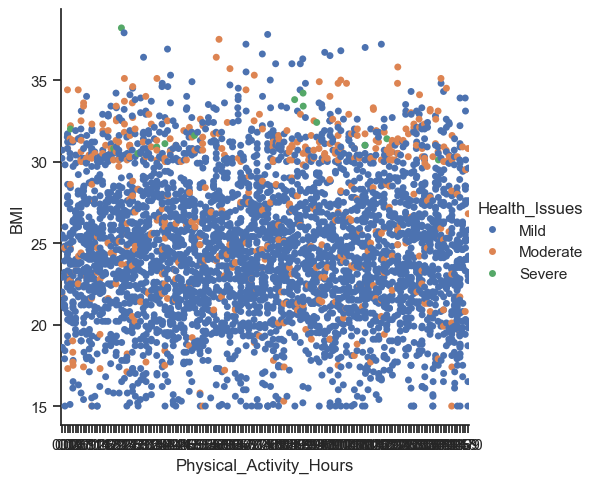

In [32]:
m = sns.catplot(x="Physical_Activity_Hours", y="BMI", hue="Health_Issues", data=df)

From this visualisation it is not clear if increased physical acivity leads to a lower BMI. Howver there appears to be a relationship between BMI and health issues, with a higher concentration of moderate and high health issues occuring in people with a BMI of 30+. As mentioned previously, exploring the relationship between BMI and Health Issues might be interesting.

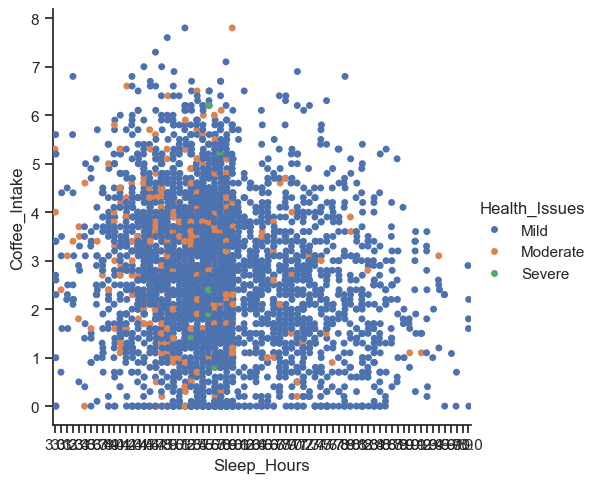

In [33]:
m = sns.catplot(x="Sleep_Hours", y="Coffee_Intake", hue="Health_Issues", data=df)

There are a few interesting observations from this visualisation:
- there appears to be a slight negative correlation between coffee intake and the number of hours - those who sleep longer drink less coffee
- Whilst in terms of overal numbers most people sleep between 4 and 6 hours, there is also a higher concentration of people with moderate health issues in those who sleep less and all those who have severe health issues sleep for less than 6 hours

A few hypotheses that have started to emerge which can be tested subsequently:
- Drinking coffee tends to lower stress levels but increases BMI
- Younger people with higher stress levels drink more coffee
- The less coffee we drink the more hours we sleep and leading to less health issues